# Bank Customer Churn: Class Imbalance Methods

This notebook compares several imbalance-handling strategies for a binary churn classification problem.

The goal is not only to train a Logistic Regression model, but to write the workflow in a clean, repeatable, and professional machine learning style:

- central configuration
- train/test split before preprocessing
- `ColumnTransformer` + `Pipeline`
- model/experiment registry
- one evaluation loop
- clean result table
- saved best full pipeline with `joblib`


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib

import numpy as np
import pandas as pd
import sklearn  

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
sklearn.set_config(transform_output="pandas")  

## Configuration

In [2]:
CONFIG = {
    "data": {
        "path": "../data/Bank Customer Churn Prediction.csv",
        "target": "churn",
        "drop_columns": ["customer_id"],
        "test_size": 0.2,
        "stratify": True,
    },

    "global": {
        "seed": 42,
        "max_iter": 1000,
        "threshold": 0.5,
    },

    "evaluation": {
        "optimize_metric": "f1",
        "report_metrics": [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
        ],
    },

    "artifacts": {
        "model_dir": "../models",
        "best_model_name": "best_churn_imbalance_pipeline.joblib",
        "results_dir": "../outputs",
        "results_name": "churn_imbalance_results.csv",
    },
}

## Load and inspect data

In [3]:
df = pd.read_csv(CONFIG["data"]["path"])

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (10000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [5]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

## Target balance

In [6]:
target = CONFIG["data"]["target"]

class_counts = df[target].value_counts().sort_index()
class_percentages = df[target].value_counts(normalize=True).sort_index() * 100

target_balance = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages.round(2),
})

target_balance

,count,percentage
churn,,
0,7963,79.63
1,2037,20.37


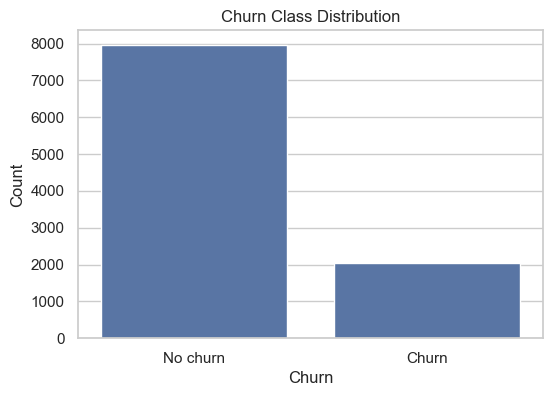

In [7]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
)

plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks([0, 1], ["No churn", "Churn"])
plt.show()

## Prepare features and target

In [8]:
X = df.drop(columns=CONFIG["data"]["drop_columns"] + [target])
y = df[target]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
Categorical features: ['country', 'gender']


In [9]:
stratify_target = y if CONFIG["data"]["stratify"] else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=CONFIG["data"]["test_size"],
    random_state=CONFIG["global"]["seed"],
    stratify=stratify_target,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Train target balance:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Test target balance:")
print(y_test.value_counts(normalize=True).round(3))

Train shape: (8000, 10)
Test shape: (2000, 10)

Train target balance:
churn
0    0.796
1    0.204
Name: proportion, dtype: float64

Test target balance:
churn
0    0.796
1    0.204
Name: proportion, dtype: float64


## Build preprocessing pipeline

In [10]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_transformer = SklearnPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = SklearnPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )


preprocessor = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
)

## Define imbalance experiments

In [11]:
EXPERIMENTS = {
    "baseline": {
        "sampler": None,
        "model_params": {
            "class_weight": None,
        },
    },

    "random_over_sampler": {
        "sampler": RandomOverSampler(random_state=CONFIG["global"]["seed"]),
        "model_params": {
            "class_weight": None,
        },
    },

    "smote": {
        "sampler": SMOTE(random_state=CONFIG["global"]["seed"]),
        "model_params": {
            "class_weight": None,
        },
    },

    "adasyn": {
        "sampler": ADASYN(random_state=CONFIG["global"]["seed"]),
        "model_params": {
            "class_weight": None,
        },
    },

    "random_under_sampler": {
        "sampler": RandomUnderSampler(random_state=CONFIG["global"]["seed"]),
        "model_params": {
            "class_weight": None,
        },
    },

    "edited_nearest_neighbours": {
        "sampler": EditedNearestNeighbours(),
        "model_params": {
            "class_weight": None,
        },
    },

    "class_weight_balanced": {
        "sampler": None,
        "model_params": {
            "class_weight": "balanced",
        },
    },

    "class_weight_custom_1_to_10": {
        "sampler": None,
        "model_params": {
            "class_weight": {0: 1, 1: 10},
        },
    },
}

In [12]:
def build_model(preprocessor, sampler=None, model_params=None):
    model_params = model_params or {}

    classifier = LogisticRegression(
        max_iter=CONFIG["global"]["max_iter"],
        random_state=CONFIG["global"]["seed"],
        **model_params,
    )

    if sampler is None:
        return SklearnPipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", classifier),
            ]
        )

    return ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("sampler", sampler),
            ("classifier", classifier),
        ]
    )

## Train and evaluate all experiments

In [13]:
def evaluate_classifier(model, X_test, y_test, threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }


trained_models = {}
results = []

for experiment_name, experiment_config in EXPERIMENTS.items():
    model = build_model(
        preprocessor=preprocessor,
        sampler=experiment_config["sampler"],
        model_params=experiment_config["model_params"],
    )

    model.fit(X_train, y_train)

    metrics = evaluate_classifier(
        model=model,
        X_test=X_test,
        y_test=y_test,
        threshold=CONFIG["global"]["threshold"],
    )

    trained_models[experiment_name] = model
    results.append({
        "experiment": experiment_name,
        **metrics,
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(CONFIG["evaluation"]["optimize_metric"], ascending=False)
    .reset_index(drop=True)
)

results_df

,experiment,accuracy,precision,recall,f1,roc_auc,pr_auc
0,random_over_sampler,0.7160,0.391069,0.710074,0.504363,0.778120,0.469027
1,smote,0.7175,0.390884,0.695332,0.500442,0.775364,0.465535
2,class_weight_balanced,0.7135,0.387228,0.700246,0.498688,0.777165,0.467919
3,random_under_sampler,0.7035,0.378906,0.714988,0.495319,0.774673,0.467613
4,adasyn,0.6975,0.373077,0.714988,0.490312,0.766827,0.463134
5,edited_nearest_neighbours,0.7925,0.489130,0.442260,0.464516,0.764393,0.472329
6,class_weight_custom_1_to_10,0.4600,0.263528,0.921376,0.409836,0.777334,0.459944
7,baseline,0.8080,0.589147,0.186732,0.283582,0.774758,0.478928


## Model comparison

In [14]:
metric_columns = CONFIG["evaluation"]["report_metrics"]

display(
    results_df.style.format({
        metric: "{:.3f}" for metric in metric_columns
    })
)

,experiment,accuracy,precision,recall,f1,roc_auc,pr_auc
0,random_over_sampler,0.716,0.391,0.710,0.504,0.778,0.469
1,smote,0.718,0.391,0.695,0.500,0.775,0.466
2,class_weight_balanced,0.714,0.387,0.700,0.499,0.777,0.468
3,random_under_sampler,0.704,0.379,0.715,0.495,0.775,0.468
4,adasyn,0.698,0.373,0.715,0.490,0.767,0.463
5,edited_nearest_neighbours,0.792,0.489,0.442,0.465,0.764,0.472
6,class_weight_custom_1_to_10,0.460,0.264,0.921,0.410,0.777,0.460
7,baseline,0.808,0.589,0.187,0.284,0.775,0.479


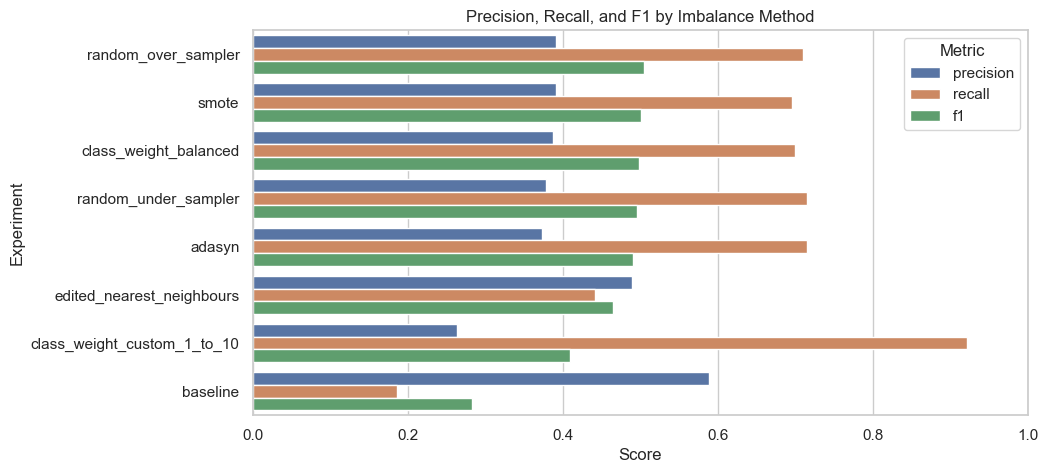

In [15]:
plot_df = results_df.melt(
    id_vars="experiment",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="score",
    y="experiment",
    hue="metric",
)

plt.title("Precision, Recall, and F1 by Imbalance Method")
plt.xlabel("Score")
plt.ylabel("Experiment")
plt.xlim(0, 1)
plt.legend(title="Metric")
plt.show()

## Best model

In [16]:
best_experiment = results_df.loc[0, "experiment"]
best_model = trained_models[best_experiment]

print("Best experiment:", best_experiment)
print("Optimized by:", CONFIG["evaluation"]["optimize_metric"])
print()
print(results_df.loc[0])

Best experiment: random_over_sampler
Optimized by: f1

experiment    random_over_sampler
accuracy                    0.716
precision                0.391069
recall                   0.710074
f1                       0.504363
roc_auc                   0.77812
pr_auc                   0.469027
Name: 0, dtype: object


In [17]:
y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_proba_best >= CONFIG["global"]["threshold"]).astype(int)

print(classification_report(y_test, y_pred_best, target_names=["No churn", "Churn"]))

              precision    recall  f1-score   support

    No churn       0.91      0.72      0.80      1593
       Churn       0.39      0.71      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



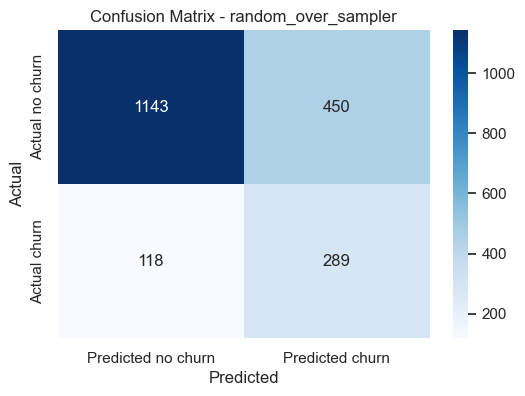

In [18]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted no churn", "Predicted churn"],
    yticklabels=["Actual no churn", "Actual churn"],
)

plt.title(f"Confusion Matrix - {best_experiment}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

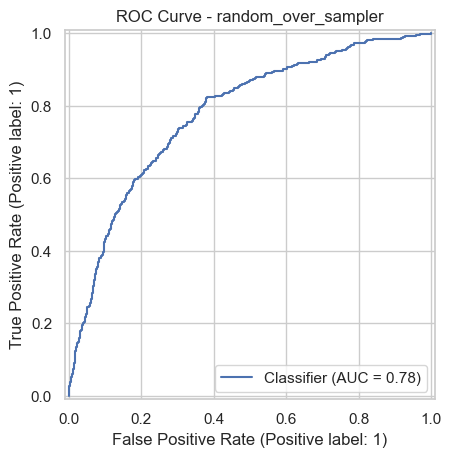

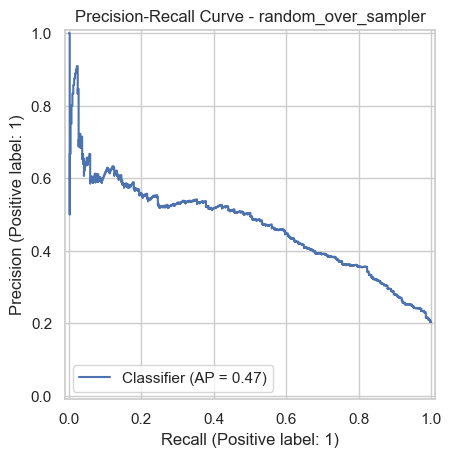

In [19]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title(f"ROC Curve - {best_experiment}")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_best)
plt.title(f"Precision-Recall Curve - {best_experiment}")
plt.show()

## Save results and best model

In [20]:
model_dir = Path(CONFIG["artifacts"]["model_dir"])
results_dir = Path(CONFIG["artifacts"]["results_dir"])

model_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / CONFIG["artifacts"]["best_model_name"]
results_path = results_dir / CONFIG["artifacts"]["results_name"]

joblib.dump(best_model, model_path)
results_df.to_csv(results_path, index=False)

print("Saved best model to:", model_path)
print("Saved results to:", results_path)

Saved best model to: ..\models\best_churn_imbalance_pipeline.joblib
Saved results to: ..\outputs\churn_imbalance_results.csv


In [21]:
loaded_model = joblib.load(model_path)

sample_predictions = loaded_model.predict(X_test.head())
sample_predictions

array([0, 1, 0, 0, 0])